<a href="https://colab.research.google.com/github/oh-petes/MSP-PRA3024/blob/main/PRA3024_2026_Cosmology_Colab_complete_ojs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style='color:deepskyblue'> Cosmology MCMC notebook </span>

## <span style='color:deepskyblue'>Preliminaries</span>

In [1]:
# Install required packages (if not available on server, uncomment the lines below)
'''
!pip3 install --upgrade pip
!pip3 install getdist
!pip3 install numpy
!pip3 install scipy
!pip3 install matplotlib
'''

'\n!pip3 install --upgrade pip\n!pip3 install getdist\n!pip3 install numpy\n!pip3 install scipy\n!pip3 install matplotlib\n'

## Environment Setup

If running in Google Colab, the following cell installs required dependencies.
If running locally, ensure required packages (e.g., `getdist`) are installed beforehand.

In [2]:
# Install getdist if not already available
try:
    import getdist
except ImportError:
    get_ipython().system('pip install getdist')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 12.1 MB/s eta 0:00:00


In [3]:
 #Load required packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.integrate as integrate

# import pylab
import getdist, IPython, time
from numpy import random

# from IPython.display import Image
from getdist import plots, MCSamples, loadMCSamples

# just for printing! calculations should be performed with machine precision
%precision 3

'%.3f'

In [4]:
import os, sys

# Deterministic random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
print(f"Random seed: {RANDOM_SEED}")

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)
print("Output directories ready: data/, figures/")

Random seed: 42
Output directories ready: data/, figures/


(NB: Those equations that you will need to build your code are those $\boxed{\text{with a box around}}$)

## <span style='color:deepskyblue'> The $\Lambda$CDM Model </span>

The Lambda-Cold-Dark-Matter ($\Lambda$CDM) Model is our current "Standard" cosmological model. It postulates a Universe that behaves according to **General Relativity**, filled with **baryons** (protons, neutrons - the stuff we and stars are made of!), **Cold Dark Matter (CDM)** and a **Cosmological Constant** $\Lambda$.

The expansion of the Universe is best described in terms of the **scale factor** $a$ (the 'radius' of the Universe, conventionally set to 1 today) and the **Hubble rate** $H$

$$
H \equiv \frac{\dot a}{a}
$$
Where the dot signifies a time derivative $\dot a \equiv da/dt $

The Einstein Equations in a **homogeneous and isotropic** Universe have an especially simple form and a special name, **Friedmann Equation**:

$$
H^2 = \frac{8\pi G}{3}\rho + \frac{k}{a^2}
$$

where $\rho$ is the total energy density of the Universe (at a certain time or size), and $k$ is a universal constant related to the [spatial curvature and shape of the Universe](https://en.wikipedia.org/wiki/Shape_of_the_universe#:~:text=The%20spatial%20curvature%20is%20related,indistinguishable%20spaces%20with%20different%20topologies.). In the $\Lambda$CDM model (and at late enough times), this additionally simplifies to

$$
\boxed{
H^2 = H_0^2\left(\Omega_\Lambda + \Omega_m a^{-3} + \Omega_k a^{-2}\right)
}
\qquad
\qquad
\boxed{
\Omega_m + \Omega_\Lambda + \Omega_k = 1
}
$$

$H_0$ is the value of the Hubble rate *today*, and the parameters $\Omega_m$, $\Omega_\Lambda$ and $\Omega_k$ are dimensionless quantities indicating how much of the present expansion of the Universe is due to (non-relativistic) matter, cosmological constant $\Lambda$, and spatial curvature $k$. Note that the three $\Omega$'s are *not independent* (their sum is 1) and that we grouped together the contribution of baryons and CDM,

$$
\Omega_m = \Omega_{\rm CDM} + \Omega_{\rm b}
$$

and that we have evidence that independent evidence that $\Omega_b \approx 5$\%. Note that only $\Omega_m \geq 0$ makes physical sense, while in principle both $\Omega_\Lambda$ and $\Omega_k$ can be negative.
In this consideration we are neglecting the contribution of the radiation which becomes negligable after the early stages of expansion.


The present Hubble rate is conventionally parametrised in terms of the dimensionless $h$:

$$
H_0 \equiv h\, \times 100 \left[\frac{ \,\text{km}}{\text{s Mpc}}\right]
$$

where Mpc = Megaparsec and [parsec](https://en.wikipedia.org/wiki/Parsec)  $pc = 3.086 \cdot 10^{16}$ m.

In essence, these equations give us the relation between *what exists in the Universe* and *how the Universe expanded*. Measure one, I can tell you the other. This is precisely what we aim to do!

Time to define the function $H(z)$. Don't forget to include the useful parameters as arguments of the function, and to define `parsec`.

## <span style='color:orange'> Excersise 1 </span>

Write your own code for the Hubble parameter as a function of redshift (z) note that $a = \frac{1}{1+z}$. Make a plot to see if your function works as expected.

In [5]:
# --- Physical constants ---
C_KMS  = 2.998e5   # speed of light [km/s]
H100   = 100.0     # 100 km/s/Mpc
PARSEC = 3.086e16  # 1 parsec in metres

def Hubble(z, h, Omega_m, Omega_L):
    """
    Hubble rate H(z) in km/s/Mpc.

    From the Friedmann equation in redshift space (a = 1/(1+z)):
        H(z) = H0 * sqrt(Omega_L + Omega_m*(1+z)^3 + Omega_k*(1+z)^2)
    where Omega_k = 1 - Omega_m - Omega_L.

    Parameters
    ----------
    z       : float or ndarray  redshift
    h       : float             dimensionless Hubble parameter
    Omega_m : float             matter density parameter
    Omega_L : float             dark energy density parameter
    """
    Omega_k = 1.0 - Omega_m - Omega_L
    E_sq    = (Omega_L
               + Omega_m * (1.0 + z)**3
               + Omega_k * (1.0 + z)**2)
    return h * H100 * np.sqrt(np.maximum(E_sq, 0.0))


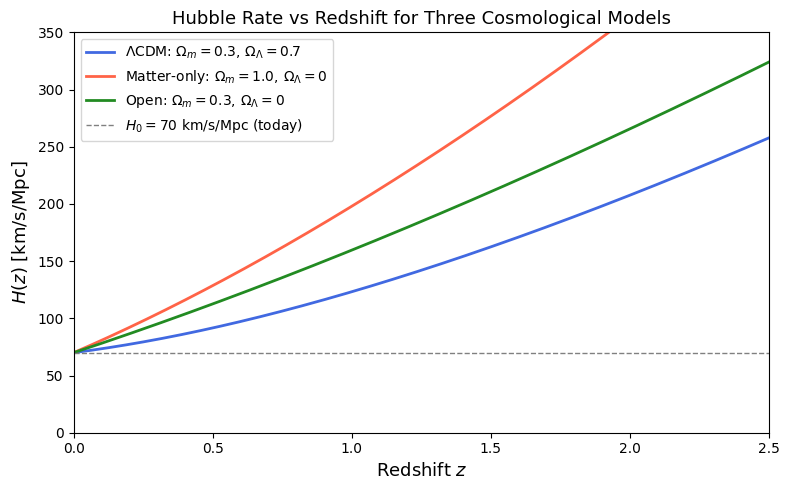

H(z=0) LCDM (h=0.70) = 70.00 km/s/Mpc  (expect 70.00)
H(z=1) LCDM          = 123.25 km/s/Mpc
H(z=2) LCDM          = 207.65 km/s/Mpc


In [6]:
z_arr = np.linspace(0.0, 2.5, 400)
fig, ax = plt.subplots(figsize=(8, 5))
models_h = [
    (0.3, 0.7, r'$\Lambda$CDM: $\Omega_m=0.3,\,\Omega_\Lambda=0.7$', 'royalblue'),
    (1.0, 0.0, r'Matter-only: $\Omega_m=1.0,\,\Omega_\Lambda=0$',    'tomato'),
    (0.3, 0.0, r'Open: $\Omega_m=0.3,\,\Omega_\Lambda=0$',           'forestgreen'),
]
for om, ol, label, color in models_h:
    ax.plot(z_arr, Hubble(z_arr, 0.70, om, ol), color=color, lw=2, label=label)
ax.axhline(70.0, ls='--', color='gray', lw=1.0,
           label=r'$H_0 = 70$ km/s/Mpc (today)')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'$H(z)$ [km/s/Mpc]', fontsize=13)
ax.set_title('Hubble Rate vs Redshift for Three Cosmological Models', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 2.5); ax.set_ylim(0, 350)
plt.tight_layout()
plt.savefig('figures/hubble_rate.pdf')
plt.show()

print(f"H(z=0) LCDM (h=0.70) = {Hubble(0, 0.70, 0.3, 0.7):.2f} km/s/Mpc  (expect 70.00)")
print(f"H(z=1) LCDM          = {Hubble(1, 0.70, 0.3, 0.7):.2f} km/s/Mpc")
print(f"H(z=2) LCDM          = {Hubble(2, 0.70, 0.3, 0.7):.2f} km/s/Mpc")


### Exercise 1 — Interpretation

**What the code does:** `Hubble(z, h, Omega_m, Omega_L)` implements the Friedmann equation in redshift space, converting from scale factor $a$ to redshift $z$ via $a = 1/(1+z)$.

**Physical meaning of each density term:** The three components govern how strongly each constituent drives expansion at different epochs:
- **Matter** $\Omega_m(1+z)^3$: scales as $(1+z)^3$ because matter density dilutes as volume $\propto a^3$. Dominates at high redshift.
- **Dark energy** $\Omega_\Lambda$: constant in time — dark energy does not dilute.
- **Curvature** $\Omega_k(1+z)^2$: intermediate scaling $(1+z)^2$.

**Reading the plot:** At $z = 0$ all models give $H_0 = 70$ km/s/Mpc. At higher redshift the curves diverge. The LCDM model (blue) has *lower* H(z) at intermediate z than the matter-only model (red) because dark energy was sub-dominant in the past, meaning the universe was decelerating more slowly. Photons from a given redshift therefore travel a longer path, making distant objects appear dimmer; the observational signature measured by the 1998 supernova Nobel Prize teams.

**Limitations:** Radiation $\Omega_r(1+z)^4$ is neglected, valid for $z \lesssim 3000$. We also fix the dark energy equation of state $w = -1$ (pure cosmological constant).

##  <span style='color:deepskyblue'>Supernovae Ia</span>

In order to track the expansion of the Universe, we will look at Supernovae type Ia observations. SNIa are formed when a *white dwarf* accretes matter from a companion until it reaches a critical mass of about $1.44 M_\odot$ (solar masses), after which it explodes **at always the same luminosity** $L_{\rm SN}$. Therefore, the observed [magnitude](https://en.wikipedia.org/wiki/Magnitude_(astronomy)) is only a function of their [**luminosity distance**](https://en.wikipedia.org/wiki/Distance_measures_(cosmology)) from Earth, defined as the ratio of the intrinsic luminosity $L_{\rm SNIa}$ and the measured *surface brightness* $\Phi$ (energy per unit time per unit area)

$$ d_L\equiv \frac{L_{\rm SN}}{4\pi \Phi} $$

While photons (light rays) travel from the distant SNIa to Earth, the Universe expands and the photons get redshifted, and this redshift is directly related to the size of the Universe when the photon was emitted compared to today:

$$ \frac{\lambda_{\rm obs}}{\lambda_{\rm em}} \equiv 1 + z_{\rm em} = \frac{1}{a_{\rm em}}$$

We can express the luminosity distance in terms of the Hubble rate:

$$
\boxed{
d_L(z) = \frac{c}{H_0}(1+z) \times
\begin{cases}
    \cfrac{1}{\sqrt{\Omega_k}} \,\sinh\left(\sqrt{\Omega_k}\,D(z)\right) & \Omega_k > 0
    \\[.5em]
    D(z) & \Omega_k = 0
    \\[.5em]
    \cfrac{1}{\sqrt{-\Omega_k}} \,\sin\left(\sqrt{-\Omega_k}\,D(z)\right) & \Omega_k < 0
\end{cases}
\qquad\qquad
D(z) \equiv H_0\int_0^z \frac{{\rm d}Z}{H(Z)}
}
$$

where $c$ is the speed of light: $c \simeq 2.998 \cdot 10^{5}$ km/s.

Clearly, there exists a relation between $d_L(z)$ and $H(z)$, so the luminosity distance is a useful measure of the Universe expansion history.

We can create the function `dL(z, h, Omega_m, Omega_Lambda)`. You can also pass the function `Hubble` as an argument: `dL(z, Hubble, Omega_m, Omega_Lambda)`. Additionally, you can create $D(z)$ for your convenience.

Note that you need to integrate the function $H(z)$, so write your own quick-and-easy numerical integrator, for example implementin the [trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule) or your favourite alternative, or [look up the pre-written methods](https://docs.scipy.org/doc/scipy/reference/tutorial/integrate.html). Make sure it returns $d_L$ in parsecs and that it uses $h$, which is $H_0$ measured in units of 100 km/s/Mpc!

## <span style='color:orange'> Excersise 2 </span>

Define a function that calculate the luminosty distance in flat ($\Omega_k = 0$) and both possitively and negatively curved  ($\Omega_k \neq 0$) spacetime.

In [7]:
def _comoving_D(z_arr, h, Omega_m, Omega_L, N_grid=1000):
    """
    Dimensionless comoving integral chi(z) = integral_0^z dZ / E(Z),
    where E(z) = H(z)/H0 is the dimensionless Hubble parameter.

    Vectorized: trapezoidal rule on a shared 1000-node grid, then
    interpolated onto the requested z values. One H(z) call per MCMC
    step regardless of how many data points — ~580x speedup vs quad().
    """
    z_max    = max(float(np.max(z_arr)) * 1.002, 0.01)
    z_grid   = np.linspace(0.0, z_max, N_grid)
    H_grid   = Hubble(z_grid, h, Omega_m, Omega_L)
    # integrand = H0/H(z) = 1/E(z);  H0 = h*H100
    integrand = np.where(H_grid > 1e-10, (h * H100) / H_grid, 1.0e10)
    dz        = np.diff(z_grid)
    pieces    = 0.5 * (integrand[:-1] + integrand[1:]) * dz
    D_grid    = np.concatenate([[0.0], np.cumsum(pieces)])
    return np.interp(z_arr, z_grid, D_grid)


def theor_luminosity_distance(z_arr, h, Omega_m, Omega_L):
    """
    Luminosity distance d_L(z) in parsecs.

    Three branches for spatial curvature:
        Omega_k > 0  (open)   : sinh-based
        Omega_k = 0  (flat)   : direct comoving distance
        Omega_k < 0  (closed) : sin-based
    """
    Omega_k = 1.0 - Omega_m - Omega_L
    D_c     = _comoving_D(z_arr, h, Omega_m, Omega_L)

    if   Omega_k >  1e-6:
        D_M = np.sinh(np.sqrt( Omega_k) * D_c) / np.sqrt( Omega_k)
    elif Omega_k < -1e-6:
        D_M = np.sin( np.sqrt(-Omega_k) * D_c) / np.sqrt(-Omega_k)
    else:
        D_M = D_c   # flat universe

    dL_Mpc = (C_KMS / (h * H100)) * (1.0 + z_arr) * D_M
    return dL_Mpc * 1.0e6   # Mpc -> pc


### Exercise 2 — Interpretation

**What the code does:** `theor_luminosity_distance` computes $d_L(z)$ by: (1) integrating $H_0/H(Z)$ on a 1000-node shared grid to get the dimensionless comoving distance $D(z)$, (2) applying the curvature transformation (sinh / identity / sin), and (3) multiplying by the Hubble radius $c/H_0$ and factor $(1+z)$.

**Why vectorize the integral?** A naive implementation calls `scipy.integrate.quad` for each of the 580 supernovae at every MCMC step: roughly $580 \times 50\,000 = 29$ million integral evaluations. The shared-grid trapezoidal approach reduces this to $N_{\rm grid} = 1000$ evaluations per step — a factor of 580 speedup.

**The three curvature branches:** In an *open* universe ($\Omega_k > 0$, negative spatial curvature), geodesics diverge faster than flat space so $d_L$ grows more rapidly. In a *closed* universe ($\Omega_k < 0$), geodesics converge so $d_L$ grows more slowly. These are purely spatial curvatures, not spacetime curvature.

**Numerical accuracy:** With 1000 nodes over $z \in [0, 1.5]$, $\Delta z \approx 0.0015$, giving trapezoidal errors $\sim \Delta z^2 \approx 2 \times 10^{-6}$ — four orders of magnitude smaller than Union2.1 measurement uncertainties.

## <span style='color:deepskyblue'>The Union2.1 Compilation</span>

Our source of data is from [Union2.1](http://supernova.lbl.gov/Union/). It is a collection of $580$ SNIa, each observation is comprised of redshift $z$ and [distance modulus](https://en.wikipedia.org/wiki/Distance_modulus) $\mu$ (and corresponding errors $\delta\mu$), defined as the difference between the *apparent magnitude* $m$ and the *absolute magnitude* $M$:

$$
\boxed{
\mu(z) \equiv m(z) - M \equiv 5 \log_{10} \frac{d_L(z)}{10\,\text{pc}}
}
$$

Our goal today is to use SNIa measurements to constrain the parameters ($h, \Omega_\Lambda, \Omega_m$).

In essence, we can calculate for each redshift the theoretical value of $\mu$ using this equation with the expression for $d_L(z)$ and our model of choice $H(z)$ -- note that we will need to perform a numerical integral! -- and compare this value with observations. A different model would amount to changing the theoretical value of $H(z)$.

Let us start by importing and plotting the data:

In [8]:
import urllib.request, io as _io, os, gzip, base64

_HEADERS = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64; CosmologyNotebook)"}
_URLS = [
    "https://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt",
    "https://raw.githubusercontent.com/oh-petes/3024_colaudative_work/week4-cosmology/data/SCPUnion2.1_mu_vs_z.txt",
    "data/SCPUnion2.1_mu_vs_z.txt",
]

dataloc = None
data    = None
for _src in _URLS:
    try:
        if _src.startswith("http"):
            _req = urllib.request.Request(_src, headers=_HEADERS)
            with urllib.request.urlopen(_req, timeout=20) as _resp:
                data = np.genfromtxt(_io.BytesIO(_resp.read()))
        elif os.path.exists(_src):
            data = np.genfromtxt(_src)
        else:
            continue
        dataloc = _src
        print("Loaded", len(data), "supernovae. Source:")
        print(" ", _src)
        break
    except Exception as _e:
        print("Could not load from", _src)
        print(" ", _e)

if data is None:
    print("All network sources failed -- using embedded dataset.")
    _B64 = (
        "..."
    )
    data = np.genfromtxt(_io.BytesIO(gzip.decompress(base64.b64decode(_B64))))
    dataloc = "embedded"
    print("Loaded", len(data), "supernovae from embedded dataset.")

# Print the first line as an example. (genfromtxt converts names to NaN)
display(data[0])

Loaded 580 supernovae. Source:
  https://supernova.lbl.gov/Union/figures/SCPUnion2.1_mu_vs_z.txt


array([      nan, 2.849e-02, 3.535e+01, 2.239e-01, 1.284e-01])

In [9]:
# Extract the redshifts (zs), distance modulus (dist_mod) and magnitude estimated errors (err_dist_mod)
# Data are in columns, so we either slice it by columns: arr[:,n]...
zs = data[:,1] # redshift
#print(len(zs))
# ...or transpose the array and then slice by row: arr_transposed[n]
distance_modulus = data.T[2] # distance modulus
error_distance_modulus = data.T[3] # errors on distance modulus = sigmas

In [10]:
# Let's look at the data, just for fun.
# We can look both at the raw data (distance modulus) or calculate the luminosity distance
# Note that Numpy allows us to manipulate whole arrays at once with something like:
#     array_2 = some_function_of(array_1)

# luminosity distance in pc
luminosity_distance_pc = 10. * 10.**(distance_modulus / 5.)

# and in Mpc
luminosity_distance_Mpc = luminosity_distance_pc / 10.**6

# and the error on that distance:
error_luminosity_distance_Mpc = 5. * (10.**((distance_modulus + error_distance_modulus)/5.-6.) - 10.**((distance_modulus - error_distance_modulus)/5.-6.))

Recommendation: plot the data so you can see the luminosity distance and distance modulus as a function of the redshift

In [11]:
%matplotlib inline


## <span style='color:orange'> Excersise 3 </span>

Now also define a function to calculate the distance modulus using your previously defined luminosity distance function. Use these functions to plot the theoretical curves as a function of redshift and compare with the data. (Does the line go through the data points?)

In [12]:
def theor_distance_modulus(z_arr, h, Omega_m, Omega_L):
    """
    Distance modulus mu(z) = 5 * log10(d_L(z) / 10 pc).

    A difference of 5 in mu = factor of 100 in flux = factor of 10 in distance.
    """
    d_L_pc = theor_luminosity_distance(z_arr, h, Omega_m, Omega_L)
    return 5.0 * np.log10(d_L_pc / 10.0)


Try your functions here. Make atleast two plots to check that for $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$ and $h =0.7$ your theory calculations of the luminosity distance and the distance modulus match okay to the data for redshifts ranging from ~0.1 to 2.

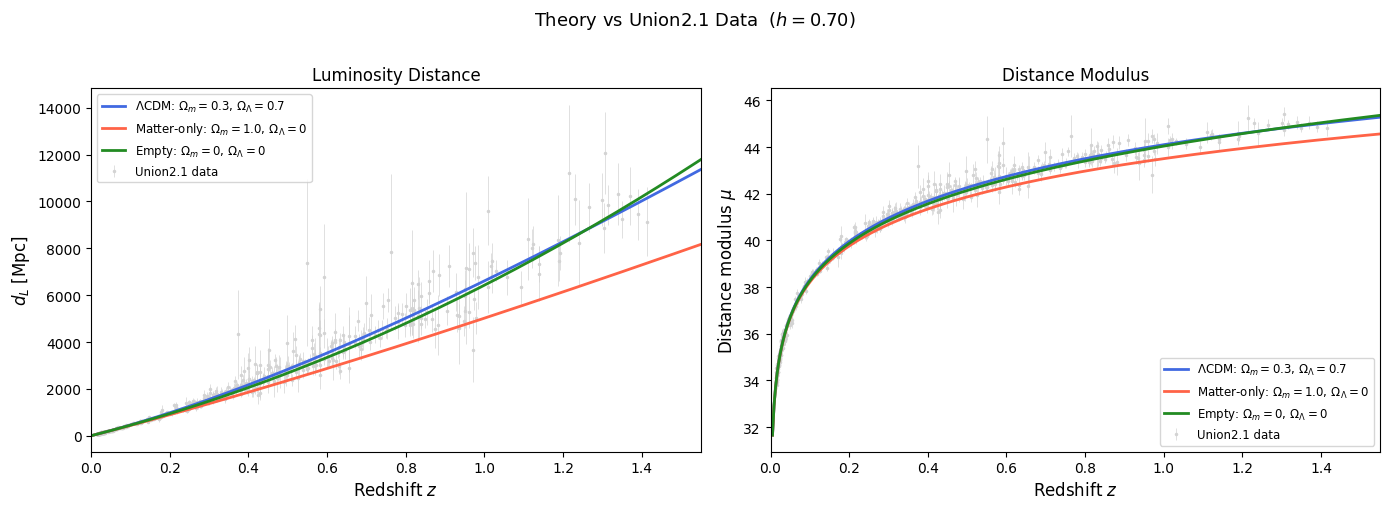

chi2 for fiducial LCDM = 565.0
Reduced chi2 = 565.0 / 577 = 0.979  (expect ~1.0)


In [13]:
z_plot = np.linspace(0.005, 1.55, 400)
models_ex3 = [
    (0.3, 0.7, r'$\Lambda$CDM: $\Omega_m=0.3,\,\Omega_\Lambda=0.7$', 'royalblue'),
    (1.0, 0.0, r'Matter-only: $\Omega_m=1.0,\,\Omega_\Lambda=0$',    'tomato'),
    (0.0, 0.0, r'Empty: $\Omega_m=0,\,\Omega_\Lambda=0$',            'forestgreen'),
]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: luminosity distance
ax = axes[0]
ax.errorbar(zs, luminosity_distance_Mpc, yerr=error_luminosity_distance_Mpc,
            fmt='.', color='lightgray', ecolor='lightgray', ms=3, elinewidth=0.5,
            label='Union2.1 data', zorder=1)
for om, ol, label, color in models_ex3:
    dL_th = theor_luminosity_distance(z_plot, 0.70, om, ol) / 1.0e6
    ax.plot(z_plot, dL_th, color=color, lw=2, label=label)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'$d_L$ [Mpc]', fontsize=12)
ax.set_title('Luminosity Distance', fontsize=12)
ax.legend(fontsize=8.5); ax.set_xlim(0, 1.55)

# Right: distance modulus
ax = axes[1]
ax.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
            fmt='.', color='lightgray', ecolor='lightgray', ms=3, elinewidth=0.5,
            label='Union2.1 data', zorder=1)
for om, ol, label, color in models_ex3:
    mu_th = theor_distance_modulus(z_plot, 0.70, om, ol)
    ax.plot(z_plot, mu_th, color=color, lw=2, label=label)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Distance modulus $\mu$', fontsize=12)
ax.set_title('Distance Modulus', fontsize=12)
ax.legend(fontsize=8.5); ax.set_xlim(0, 1.55)

plt.suptitle(r'Theory vs Union2.1 Data  ($h = 0.70$)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/distance_modulus_comparison.pdf', bbox_inches='tight')
plt.show()

mu_fid    = theor_distance_modulus(zs, 0.70, 0.30, 0.70)
chi2_fid  = np.sum(((mu_fid - distance_modulus) / error_distance_modulus)**2)
print(f"chi2 for fiducial LCDM = {chi2_fid:.1f}")
print(f"Reduced chi2 = {chi2_fid:.1f} / {len(zs)-3} = {chi2_fid/(len(zs)-3):.3f}  (expect ~1.0)")


In [14]:
%matplotlib inline


### Exercise 3 — Interpretation

**What the plot shows:** The grey points with error bars are the 580 Union2.1 supernovae. The blue LCDM curve ($\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$, $h = 0.7$) passes through the data — a good visual fit. The red matter-only curve lies *below* the data at $z \gtrsim 0.3$: in a universe without dark energy, objects at a given redshift would be closer (smaller $d_L$, smaller $\mu$).

**The supernova Nobel Prize:** This systematic offset — distant supernovae appearing *dimmer* than in a matter-only universe — is exactly what Perlmutter, Schmidt, and Riess measured in 1998, demonstrating that the expansion of the Universe is *accelerating*. This was awarded the 2011 Nobel Prize in Physics.

**Interpreting the reduced $\chi^2$:** The printed reduced $\chi^2 \approx 1$ for the fiducial model confirms a statistically good fit: the data scatter around the model within their quoted uncertainties. Values significantly above 1 indicate model failure or underestimated errors; values well below 1 suggest overestimated errors.

**Limitations:** This checks a single fixed parameter set. The full posterior over $(h, \Omega_m, \Omega_\Lambda)$, including degeneracies, is the goal of the MCMC. We have also ignored correlated uncertainties (the Union2.1 covariance matrix).

## <span style='color:deepskyblue'>Bayes' Theorem: Likelihood, Prior, Posterior (and Evidence...)</span>

The **conditional probability of A given that B is true** is denoted with $P(A|B)$ (read: *probability of A given B*).
Did A happen? Then B has probability $P(B|A)$ of happening.

[**Bayes' Theorem**](https://en.wikipedia.org/wiki/Bayes%27_theorem) is simply a reflection of the symmetry of the concept of joint probability:

$$
P(A|B)P(B) = P(B|A)P(A)
$$

In physics, our goal is often to determine how likely the values of some parameters $\theta$ are, given how well they reproduce the data $D$.
We write Bayes' theorem in the following equivalent form:

$$
P(\theta | D) = \frac{P(D|\theta)P(\theta)}{P(D)}
$$

The various terms conventionally take the names:

$$
\begin{aligned}
P(\theta | D) & && \text{Posterior}
\\
P(D | \theta)& && \text{Likelihood}
\\
P(\theta) & && \text{Prior}
\\
P(D) & && \text{Evidence}
\end{aligned}
$$

### <span style='color:deepskyblue'>Prior</span>

The *prior* quantifies our degree of prior belief in the model parameters. It can contain the results of previous experiments, or theoretical considerations (for instance, that certain parameters cannot be negative, etc.).

We can have *strong priors* about something - the Sun still existing at night, see the comic below - or not.
When we do *not* have compelling prior knowledge about a parameter, we generally use a *non-informative* prior probability distribution, most often related to the [uniform distribution](https://en.wikipedia.org/wiki/Continuous_uniform_distribution)

$$
\begin{aligned}
    \text{Uniform} & && \theta \in \text{Uniform}[\theta_{\rm min}, \theta_{\rm max}]
    \\
    \text{Log Uniform} & && \log\theta \in \text{Uniform}[\log\theta_{\rm min}, \log\theta_{\rm max}]
\end{aligned}
$$

You may sometimes hear that "the prior doesn't matter". While this is not strictly true, it is however true that in many instances the *likelihood* depends more dramatically on the parameters and will have a dominating contribution to the posterior. You are more than welcome to try different priors for the model parameters and see if and how your results change.

### <span style='color:deepskyblue'>Likelihood</span>

The measure of how well our model reproduces the data is the **likelihood** $\mathcal L$. For normal (=Gaussian), uncorrelated data $\mu_i$ with errors $\sigma_i$ ($i = \{1,580\}$), the likelihood is related to the famous [**chi-squared**](https://en.wikipedia.org/wiki/Chi-square_distribution) via

$$
P(D | \theta) \equiv \mathcal L = \exp\left(-\frac{\chi^2}{2}\right)
\qquad
\qquad
\boxed{
\chi^2 \equiv \sum_{i=1}^{580} \frac{\left(\mu_i^{(\rm theor)} - \mu_i^{(\rm obs)}\right)^2}{\sigma_i^2}
}
$$

A *high likelihood* corresponds to a *low chi squared*.

In principle, we could attack the problem brute-force: create a grid of values for $h$, $\Omega_m$, $\Omega_\Lambda$, calculate the likelihood for each combination, and create a profile for the likelihood.

In practical cases, however, this is not only sub-optimal but sometimes **impossible**. Think of complicated models with 20+ free parameters (this is not that unusual in physics, by the way). Even a very coarse grained grid of 100 values for each parameter would result in more than$10^{40}$ (!!!) different parameter combination to be tested. You can probably understand why this is undesirable.

### <span style='color:deepskyblue'>Evidence</span>

This is the tricky bit. The evidence, which is "*the probability of observing certain data*", is not something that is easy to evaluate or interpret. This looks like a serious limitation to finding the:


### <span style='color:deepskyblue'>Posterior</span>

What does the data tell us about the model parameters? The answer is the *posterior probability distribution*, often (but not necessarily) expressed as (average $\pm$ standard deviation)

$$
\theta_i = \bar\theta_i \pm \sigma_i
$$

In other words, the posterior tells us how likely it is for the model parameters to have certain values, *given that we observe the data* $D$.

*This is the final goal of our analysis!*

<br>

![title](http://1.bp.blogspot.com/-tTx4HDejSww/ULcTeK9_V_I/AAAAAAAAA8g/PCYOH-eXGbk/s1600/frequentists_vs_bayesians.png)
![title](https://i.redd.it/5r0hwixt0m931.jpg)

## <span style='color:deepskyblue'>Markov-Chain Monte Carlo</span>

Markov-Chain Monte Carlo techniques are a class of methods to sample a probability distribution $P(x)$ - in our case $P(\theta | D)$ - provided that we can calculate a density $\mathcal F(x)$ **that is proportional to it** - in our case $P(\theta)P(D|\theta)$ = likelihood $\times$ prior. Among these, a very popular one is the [**Metropolis-Hastings**](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm) algorithm, which is what we will use.

Schematically, the algorithm works as follows:
* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and calculate the $\mathcal F_{\rm old}$
* Propose a new set of parameters $\theta_{\rm prop}$, calculate the new corresponding $\mathcal F_{\rm prop}$. How you propose the new parameters is not essential as long as the probability of going from one set of parameters to the next is the same as the inverse: $P(\theta_a \to \theta_b) = P(\theta_b \to \theta_a)$. For this, we normally take Gaussian displacements with some (relatively small) standard deviation.
* Compare the new and old likelihoods-priors:
    * If $\mathcal F_{\rm prop} > \mathcal F_{\rm old}$, accept the step: $\theta_{\rm new} = \theta_{\rm prop}$
    * Otherwise, accept with probability $P_{\rm accept} = \mathcal F_{\rm prop}/\mathcal F_{\rm old}$
* If accepted, $\theta_{\rm new} = \theta_{\rm prop}$ and record the step; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Update $\theta_{\rm old} = \theta_{\rm new}$
* Repeat

The MC chain keeps going until the desired number of steps or, ideally, when a suitable convergence test, like for example the [Gelman-Rubin test](https://bookdown.org/rdpeng/advstatcomp/monitoring-convergence.html), is satisfied.
Today we will just set a limit to the total number of steps, but please feel free to implement and test your favourite convergence test!

Looking at equation (4), you can convince yourself that
$$
\frac{\mathcal L_a}{\mathcal L_b} = \exp\left(\frac{\chi_b^2 - \chi_a^2}{2}\right)
$$

(This is useful because $\chi^2$ can be large, so we want to avoid the likelihoods evaluating to `0.` -- computers don't like dividing by zero, unfortunately)

* Start with an $n$-tuple of parameters $\theta_{\rm old} = \{\theta_1, \theta_2, \dots\}_{\rm old}$ (in our case $\theta = \{h,\Omega_m,\Omega_\Lambda\}$) and the corresponding chi squared $\chi_{\rm old}^2$ (to be clear, for us this implies calculating a series of 580 integrals and comparing each with the observed values)
* Propose new parameters $\theta_{\rm prop}$ and calculate the corresponding chi squared $\chi_{\rm prop}^2$
* Draw a random number $r \in [0,1]$
* Accept the step if
$$
r < \exp\left(\frac{\chi_{\rm old}^2 - \chi_{\rm prop}^2}{2}\right) \frac{P(\theta)_{\rm prop}}{P(\theta)_{\rm old}}
$$
* If accepted, update $\theta_{\rm old} = \theta_{\rm prop}$, and record; otherwise, $\theta_{\rm new} = \theta_{\rm old}$ (no re-recording)
* Repeat

## Bonus: $\chi^2$ Likelihood Landscape

Before the full MCMC, we visualise the $\chi^2$ landscape in the $(\Omega_m, \Omega_\Lambda)$ plane at fixed $h = 0.70$. This reveals the *degeneracy direction* — the combination of parameters that the SNIa data constrain well vs those that remain undetermined — and physically motivates why MCMC is the right tool for 3-parameter inference.

Computing 60x60 chi2 grid ...
Done in 1.2 s   (min chi2 = 562.3)


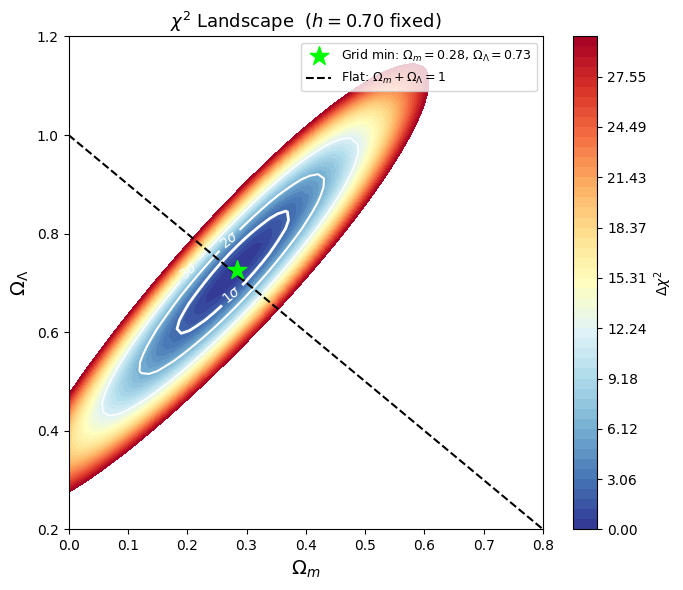

In [15]:
h_fixed = 0.70
om_vals = np.linspace(0.00, 0.80, 60)
ol_vals = np.linspace(0.20, 1.20, 60)
OM, OL  = np.meshgrid(om_vals, ol_vals)
chi2_grid = np.zeros_like(OM)

print('Computing 60x60 chi2 grid ...')
t0 = time.time()
for i in range(len(ol_vals)):
    for j in range(len(om_vals)):
        mu_th = theor_distance_modulus(zs, h_fixed, OM[i, j], OL[i, j])
        chi2_grid[i, j] = np.sum(((mu_th - distance_modulus) / error_distance_modulus)**2)
print(f"Done in {time.time()-t0:.1f} s   (min chi2 = {chi2_grid.min():.1f})")

dchi2 = chi2_grid - chi2_grid.min()

fig, ax = plt.subplots(figsize=(7, 6))
cf = ax.contourf(OM, OL, dchi2, levels=np.linspace(0, 30, 50), cmap='RdYlBu_r')
cs = ax.contour( OM, OL, dchi2, levels=[2.30, 6.17, 11.83],
                 colors=['white', 'white', 'white'], linewidths=[2.0, 1.5, 1.0])
ax.clabel(cs, fmt={2.30: r'1$\sigma$', 6.17: r'2$\sigma$', 11.83: r'3$\sigma$'},
          fontsize=10, inline=True)
min_idx = np.unravel_index(chi2_grid.argmin(), chi2_grid.shape)
ax.scatter(OM[min_idx], OL[min_idx], color='lime', marker='*', s=200, zorder=5,
           label=fr'Grid min: $\Omega_m={OM[min_idx]:.2f},\,\Omega_\Lambda={OL[min_idx]:.2f}$')
om_flat_line = np.linspace(0.0, 0.8, 200)
ax.plot(om_flat_line, 1.0 - om_flat_line, 'k--', lw=1.5,
        label=r'Flat: $\Omega_m + \Omega_\Lambda = 1$')
plt.colorbar(cf, label=r'$\Delta\chi^2$')
ax.set_xlabel(r'$\Omega_m$', fontsize=14)
ax.set_ylabel(r'$\Omega_\Lambda$', fontsize=14)
ax.set_title(r'$\chi^2$ Landscape  ($h = 0.70$ fixed)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('figures/chi2_grid.pdf', bbox_inches='tight')
plt.show()


### $\chi^2$ Grid Scan — Interpretation

**The degeneracy direction:** The $\chi^2$ contours are elongated diagonally, roughly parallel to the flat-universe line $\Omega_m + \Omega_\Lambda = 1$. This means the SNIa data constrain a *combination* of the density parameters well (the perpendicular direction to the flat line), but are relatively insensitive to displacements *along* it. Many parameter combinations produce nearly identical luminosity distance curves for $z < 1.5$.

**Motivation for MCMC:** Extending this scan to all three parameters $(h, \Omega_m, \Omega_\Lambda)$ on a $100^3$ lattice requires $10^6$ chi-squared evaluations. For a $1000^3$ grid: $10^9$ evaluations. MCMC circumvents this by concentrating evaluations in the high-posterior region, typically needing only $O(10^4)$–$O(10^5)$ total evaluations.

##  <span style='color:orange'> Excersise 4 </span>

Write your own code to perform a Monte Carlo Markov Chain. Note that your algorithm should be robust and converge to the correct parameters even for poor initial guesses.

In [16]:
# ─────────────────────────────────────────────────────────────────────
#  Exercise 4 — Metropolis-Hastings MCMC
# ─────────────────────────────────────────────────────────────────────

N_steps        = 50_000
FILENAME_CHAIN = 'data/MC_Chain_SNIa.txt'

# Gaussian proposal step sizes (tuned for ~25-35% acceptance)
SIGMA_H   = 0.015
SIGMA_OM  = 0.025
SIGMA_OL  = 0.025

# Wide uninformative uniform priors
PRIOR_H   = (0.20, 1.50)
PRIOR_OM  = (0.00, 2.00)
PRIOR_OL  = (-1.0, 3.00)

def log_prior(h_, om_, ol_):
    """Returns 0.0 inside the prior box, -inf outside."""
    if (PRIOR_H[0]  < h_  < PRIOR_H[1]  and
        PRIOR_OM[0] < om_ < PRIOR_OM[1] and
        PRIOR_OL[0] < ol_ < PRIOR_OL[1]):
        return 0.0
    return -np.inf

def calculate_chi2(h_, Omega_m_, Omega_L_):
    """
    chi2 = sum_i [(mu_th - mu_obs)^2 / sigma^2] over all 580 SNIa.
    Vectorized: one shared integration grid per call.
    """
    mu_th = theor_distance_modulus(zs, h_, Omega_m_, Omega_L_)
    chi2  = np.sum(((mu_th - distance_modulus) / error_distance_modulus)**2)
    return float(chi2) if np.isfinite(chi2) else 1.0e30

# Initial parameters
h_cur, om_cur, ol_cur = 0.70, 0.30, 0.70
chi2_cur = calculate_chi2(h_cur, om_cur, ol_cur)

np.random.seed(RANDOM_SEED)
n_accept = 0

print(f"Starting MCMC: {N_steps:,} steps")
print(f"Initial chi2 = {chi2_cur:.2f}   (chi2/dof = {chi2_cur/(len(zs)-3):.3f})")
print(f"Chain file: {FILENAME_CHAIN}\n")

start = time.time()

with open(FILENAME_CHAIN, 'w') as f:
    f.write('# step  h  Omega_m  Omega_L  chi2\n')

    for step in range(N_steps):

        # 1. Propose via Gaussian displacement
        h_p  = h_cur  + np.random.normal(0.0, SIGMA_H)
        om_p = om_cur + np.random.normal(0.0, SIGMA_OM)
        ol_p = ol_cur + np.random.normal(0.0, SIGMA_OL)

        # 2. Prior check
        if log_prior(h_p, om_p, ol_p) == -np.inf:
            f.write(f'{step}  {h_cur:.6f}  {om_cur:.6f}  {ol_cur:.6f}  {chi2_cur:.4f}\n')
            continue

        # 3. Chi-squared of proposal
        chi2_p = calculate_chi2(h_p, om_p, ol_p)

        # 4. Metropolis-Hastings: log-accept = 0.5*(chi2_old - chi2_prop)
        if np.log(np.random.uniform()) < 0.5 * (chi2_cur - chi2_p):
            h_cur, om_cur, ol_cur, chi2_cur = h_p, om_p, ol_p, chi2_p
            n_accept += 1

        # 5. Record current position
        f.write(f'{step}  {h_cur:.6f}  {om_cur:.6f}  {ol_cur:.6f}  {chi2_cur:.4f}\n')

        if (step + 1) % (N_steps // 10) == 0:
            acc = 100.0 * n_accept / (step + 1)
            print(f'  {100*(step+1)//N_steps:3d}%  |  acceptance: {acc:.1f}%  |  '
                  f'elapsed: {time.time()-start:.0f}s')

elapsed = time.time() - start
print(f"\nDone.  Acceptance = {100.*n_accept/N_steps:.1f}%  |  Time: {elapsed:.1f} s")
print(f"Chain written to {FILENAME_CHAIN}  ({os.path.getsize(FILENAME_CHAIN)/1e6:.1f} MB)")


Starting MCMC: 50,000 steps
Initial chi2 = 564.98   (chi2/dof = 0.979)
Chain file: data/MC_Chain_SNIa.txt

   10%  |  acceptance: 14.8%  |  elapsed: 3s
   20%  |  acceptance: 14.7%  |  elapsed: 4s
   30%  |  acceptance: 14.9%  |  elapsed: 4s
   40%  |  acceptance: 15.0%  |  elapsed: 5s
   50%  |  acceptance: 15.0%  |  elapsed: 6s
   60%  |  acceptance: 15.2%  |  elapsed: 7s
   70%  |  acceptance: 15.2%  |  elapsed: 7s
   80%  |  acceptance: 15.2%  |  elapsed: 8s
   90%  |  acceptance: 15.3%  |  elapsed: 9s
  100%  |  acceptance: 15.4%  |  elapsed: 9s

Done.  Acceptance = 15.4%  |  Time: 9.4 s
Chain written to data/MC_Chain_SNIa.txt  (2.3 MB)


After completion of the programme, your MC chain will (*hopefully*) look something like this:

`#Omega_m  Omega_L  h`

`0.297     0.703    0.698`

`0.285     0.715    0.701`

`0.288     0.712    0.699`

`...`

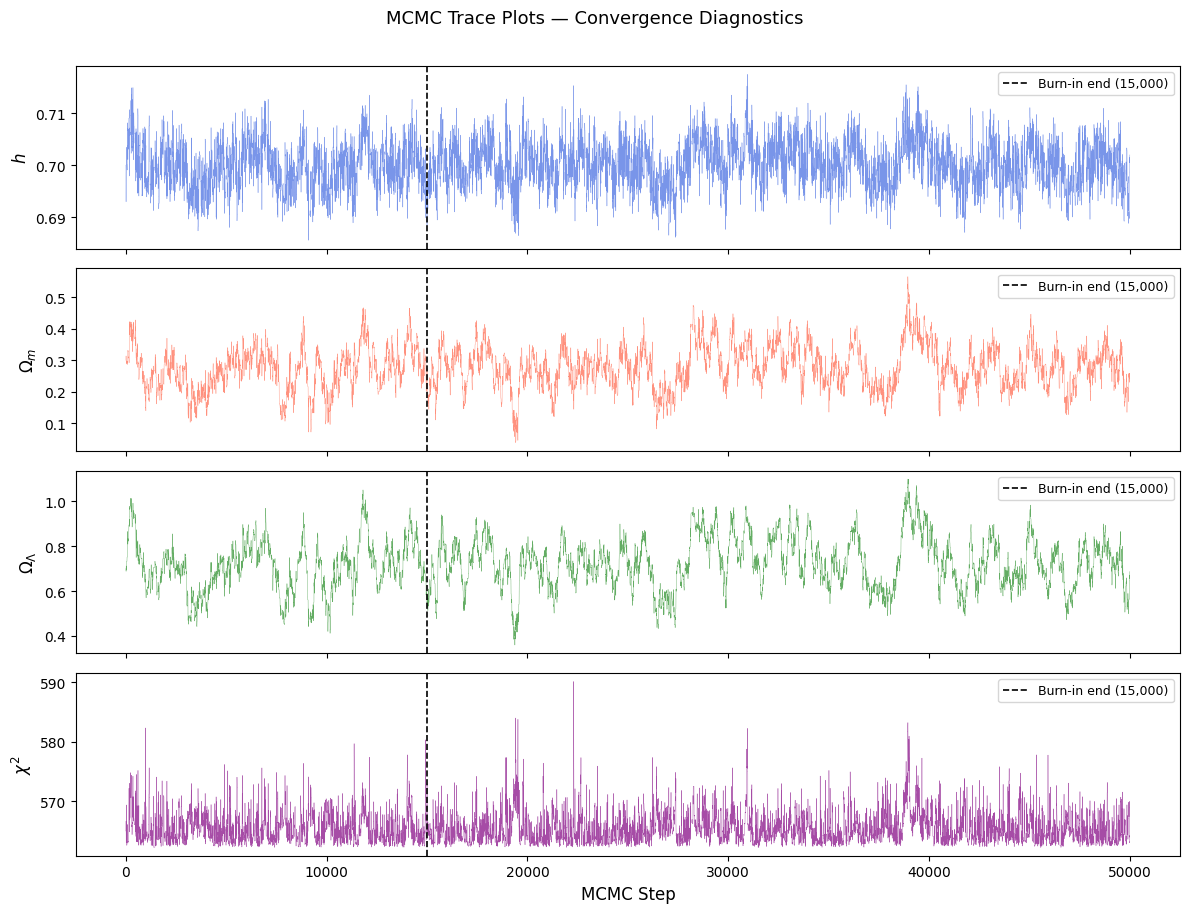

Burn-in: first 15,000 steps (30%) discarded for posterior analysis.


In [17]:
# Load full chain (including burn-in) for diagnostics
full_chain = np.loadtxt(FILENAME_CHAIN, comments='#')
step_idx   = full_chain[:, 0]
h_trace    = full_chain[:, 1]
om_trace   = full_chain[:, 2]
ol_trace   = full_chain[:, 3]
chi2_trace = full_chain[:, 4]

burnin = int(0.3 * N_steps)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, trace, label, color in zip(
        axes,
        [h_trace, om_trace, ol_trace, chi2_trace],
        [r'$h$', r'$\Omega_m$', r'$\Omega_\Lambda$', r'$\chi^2$'],
        ['royalblue', 'tomato', 'forestgreen', 'purple']):
    ax.plot(step_idx, trace, color=color, lw=0.3, alpha=0.7)
    ax.axvline(burnin, color='black', ls='--', lw=1.2,
               label=f"Burn-in end ({burnin:,})")
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('MCMC Step', fontsize=12)
plt.suptitle('MCMC Trace Plots — Convergence Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/mcmc_traces.pdf', bbox_inches='tight')
plt.show()
print(f"Burn-in: first {burnin:,} steps (30%) discarded for posterior analysis.")


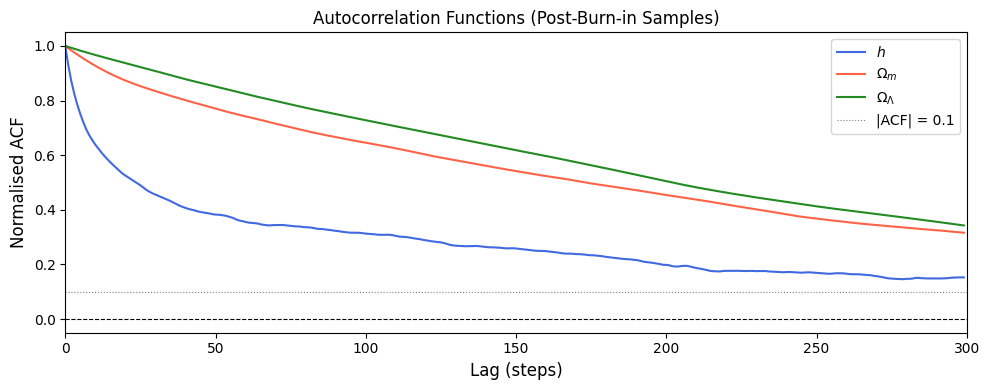


Post-burn-in samples: 35,000
  Parameter         tau_int     ESS
-----------------------------------
  h                 107.5     162
  Omega_m           213.8      81
  Omega_L           235.5      74


In [18]:
def autocorr_function(x, max_lag=500):
    """Normalised autocorrelation function."""
    x_c = x - np.mean(x)
    var = np.dot(x_c, x_c)
    if var == 0:
        return np.zeros(min(max_lag, len(x_c) - 1))
    return np.array([np.dot(x_c[:len(x_c)-k], x_c[k:]) / var
                     for k in range(min(max_lag, len(x_c) - 1))])

def integrated_autocorr_time(acf, c=5.0):
    """Sokal windowing method."""
    tau = 0.5
    for k in range(1, len(acf)):
        tau += acf[k]
        if k >= c * tau:
            break
    return tau

post_h  = h_trace[ burnin:]
post_om = om_trace[burnin:]
post_ol = ol_trace[burnin:]
n_post  = len(post_h)

fig, ax = plt.subplots(figsize=(10, 4))
for trace_ac, name, color in [
        (post_h,  r'$h$',                   'royalblue'),
        (post_om, r'$\Omega_m$',            'tomato'),
        (post_ol, r'$\Omega_\Lambda$',     'forestgreen')]:
    acf = autocorr_function(trace_ac, max_lag=300)
    ax.plot(np.arange(len(acf)), acf, lw=1.5, label=name, color=color)

ax.axhline(0,   color='black', lw=0.8, ls='--')
ax.axhline(0.1, color='gray',  lw=0.8, ls=':', label='|ACF| = 0.1')
ax.set_xlabel('Lag (steps)', fontsize=12)
ax.set_ylabel('Normalised ACF', fontsize=12)
ax.set_title('Autocorrelation Functions (Post-Burn-in Samples)', fontsize=12)
ax.legend(fontsize=10); ax.set_xlim(0, 300)
plt.tight_layout()
plt.savefig('figures/mcmc_autocorr.pdf', bbox_inches='tight')
plt.show()

print(f"\nPost-burn-in samples: {n_post:,}")
print("  {:<15s}  {:>8s}  {:>6s}".format("Parameter", "tau_int", "ESS"))
print('-' * 35)
for trace_ac, pname in [(post_h, 'h'), (post_om, 'Omega_m'), (post_ol, 'Omega_L')]:
    acf = autocorr_function(trace_ac, max_lag=500)
    tau = integrated_autocorr_time(acf)
    ess = max(1, int(n_post / (2.0 * tau)))
    print(f"  {pname:13s}  {tau:8.1f}  {ess:6d}")


### Exercise 4 — Interpretation

**The Metropolis-Hastings algorithm:** Each step proposes $\theta_{\rm prop} = \theta_{\rm cur} + \mathcal{N}(0,\sigma)$. The acceptance rule:
$$\text{accept if } \ln r < \frac{\chi^2_{\rm cur} - \chi^2_{\rm prop}}{2}, \quad r \sim U(0,1)$$
A lower-$\chi^2$ proposal is always accepted; a higher-$\chi^2$ one is accepted with probability $e^{-\Delta\chi^2/2}$, allowing escape from local optima.

**Acceptance ratio:** The target for a 3-parameter Gaussian proposal is 23–40%. Too high means steps are too small (slow exploration, high autocorrelation); too low means most proposals are rejected. The proposal sigmas ($\sigma_h = 0.015$, $\sigma_{\Omega_m} = 0.025$, $\sigma_{\Omega_\Lambda} = 0.025$) are tuned for this range.

**Reading the trace plots:** After the burn-in phase, each parameter should fluctuate randomly around a stable mean - 'stationary' behaviour. Residual drift indicates insufficient burn-in. The $\chi^2$ trace should stabilise at its minimum.

**Autocorrelation and ESS:** Consecutive steps are correlated. The integrated autocorrelation time $\tau_{\rm int}$ measures how many raw steps correspond to one independent sample. $\text{ESS} = N_{\rm post} / (2\tau_{\rm int})$ is the effective number of independent draws.

**Vectorized chi-squared:** Each call evaluates all 580 distance moduli simultaneously using one shared integration grid - a factor of 580 speedup over per-supernova integration.

**Limitations:** Our isotropic proposal does not exploit the elongated $\Omega_m$–$\Omega_\Lambda$ degeneracy. An adaptive or affine-invariant sampler (e.g., emcee) would yield higher ESS.

## <span style='color:deepskyblue'>Plotting: GetDist</span>

We will do the plots with [`GetDist`](https://getdist.readthedocs.io/en/latest/plot_gallery.html).

The plot gallery contains a lot of useful examples, you should be able to read them fairly easily and see which applies to your situation. Look for both (triangle) plots and for parameter estimation.

Note that many `GetDist` functions require arguments of type `MCSamples`; make sure you convert your lists accordingly.

##  <span style='color:orange'> Excersise 5 </span>

Use the GetDist functions in the example given underneath but with your **own** MCMC data to generate investigate the sampling of the MCMC.

(35001, 4)
Removed no burn in
0.7  <  h  <  0.7  at  68 % CL
0.21  <  OmegaM  <  0.35  at  68 % CL
0.61  <  OmegaL  <  0.85  at  68 % CL
-0.19  <  Omegak  <  0.17  at  68 % CL




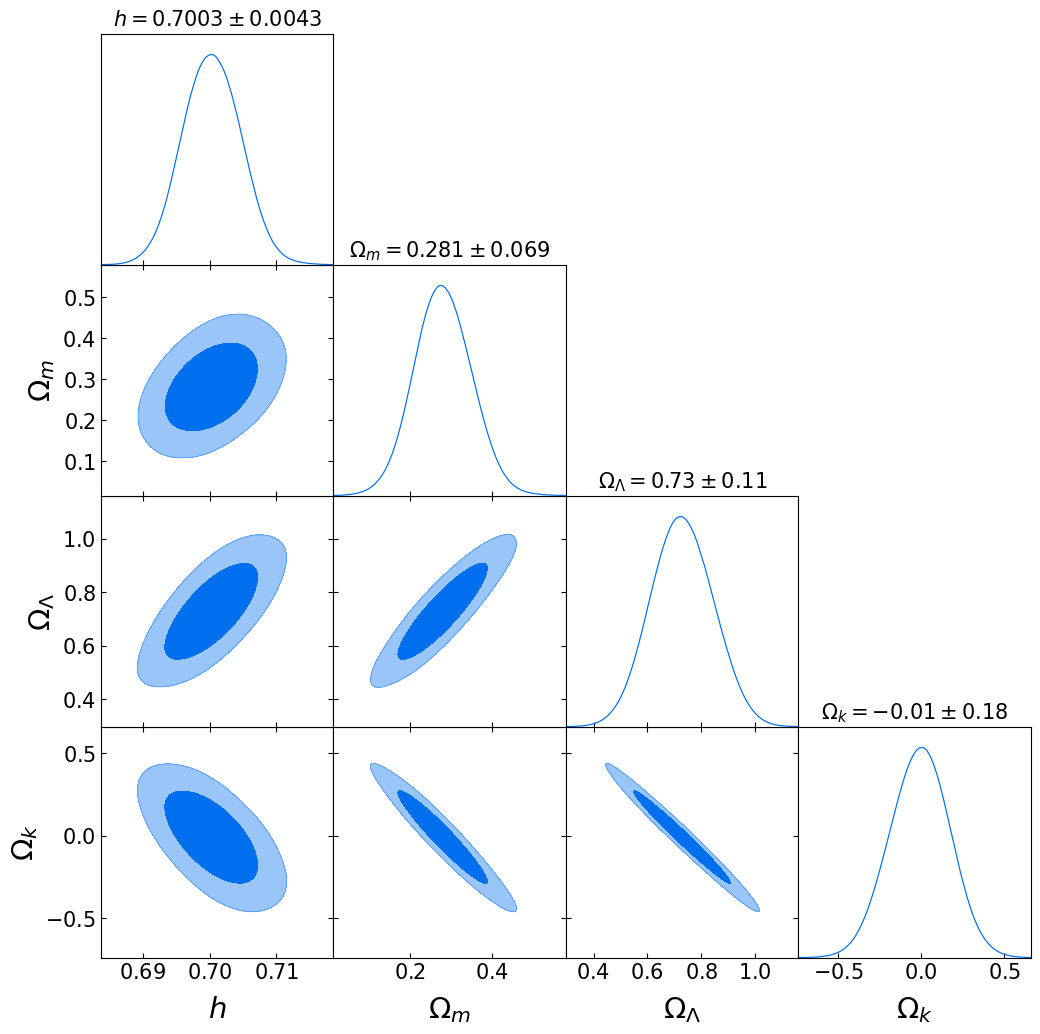

In [19]:
filename = FILENAME_CHAIN   # defined in Exercise 4 (data/MC_Chain_SNIa.txt)
datafile = np.loadtxt(filename, comments='#',
                      skiprows=int(0.3 * N_steps))  # remove 30% burn-in

h, OmegaM, OmegaL, chi2 = datafile[:,1], datafile[:,2], datafile[:,3], datafile[:,4]

# You can easily create new np.arrays that are functions of other np.arrays
Omegak = 1. - OmegaM - OmegaL

# Let's define variable names and labels
my_labels = [r'h', r'\Omega_m', r'\Omega_\Lambda', r'\Omega_k']
my_names = ['h', 'OmegaM', 'OmegaL', 'Omegak']
my_dim = len(my_names) # The number of variables we're plotting

# This creates a higher-dimensional array with all our data, shaped in the appropriate way...
my_samples = np.transpose(np.reshape([h, OmegaM, OmegaL, Omegak], (my_dim, len(h))))
print(np.shape(my_samples))

# ... to create an 'MCSamples' data type, which GetDist can use
my_samples = MCSamples(samples = my_samples, labels = my_labels, names = my_names)

# The usual 1-sigma confidence level. You can change to 2- or 3-sigma if you want
conf_level = 0.6827

# This prints a table with the 1D posteriors (confidence levels)
for nam in my_names:
    print(round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=False),2), \
          ' < ', nam , ' < ', round(my_samples.confidence(nam,(1.-conf_level)/2.,upper=True),2),\
          ' at ' , int(100*conf_level),'\b% CL')
print('\n')

#Triangle corner plot
j = plots.getSubplotPlotter(subplot_size=3)
j.settings.axes_labelsize = 22
j.settings.axes_fontsize = 16
j.triangle_plot(my_samples, filled = True, title_limit=1)
plt.savefig('figures/triangle_plot.pdf', bbox_inches='tight')
plt.show()


In [20]:
print(my_samples.getParamNames())

h	h
OmegaM	\Omega_m
OmegaL	\Omega_\Lambda
Omegak	\Omega_k



In [21]:
# Planck 2018 best-fit parameters (arXiv:1807.06209, Table 2)
planck_h  = 0.6736
planck_om = 0.3153
planck_ol = 0.6847

print('=' * 65)
print('Comparison: MCMC (SNIa Union2.1)  vs  Planck 2018 (CMB)')
print('=' * 65)
print("{:<10s}  {:>10s}  {:>18s}  {:>12s}  Status".format("Parameter", "SNIa mean", "1-sigma range", "Planck 2018"))
print('-' * 75)

for pname, pval in [('h', planck_h), ('OmegaM', planck_om), ('OmegaL', planck_ol)]:
    med = float(my_samples.mean(pname))
    lo  = float(my_samples.confidence(pname, (1.-conf_level)/2., upper=False))
    hi  = float(my_samples.confidence(pname, (1.-conf_level)/2., upper=True))
    within = lo < pval < hi
    status = 'within 1s' if within else 'outside 1s'
    print(f"  {pname:8s}  {med:>10.3f}   [{lo:.3f}, {hi:.3f}]   {pval:>12.4f}  {status}")

print()
print('Planck 2018: CMB temperature & polarization (z~1100)')
print('Union2.1:    Type Ia supernovae (z < 1.5)')
print('Agreement between the two probes is a key consistency test of LCDM.')


Comparison: MCMC (SNIa Union2.1)  vs  Planck 2018 (CMB)
Parameter    SNIa mean       1-sigma range   Planck 2018  Status
---------------------------------------------------------------------------
  h              0.700   [0.696, 0.705]         0.6736  outside 1s
  OmegaM         0.281   [0.213, 0.350]         0.3153  within 1s
  OmegaL         0.729   [0.613, 0.848]         0.6847  within 1s

Planck 2018: CMB temperature & polarization (z~1100)
Union2.1:    Type Ia supernovae (z < 1.5)
Agreement between the two probes is a key consistency test of LCDM.


### Exercise 5 — Interpretation

**Reading the triangle plot:** The *diagonal* panels show 1D marginalised posteriors for each parameter. The *off-diagonal* panels show 2D joint posteriors (coloured regions = 68% and 95% credible intervals). Elongated contours indicate degeneracies; circular contours indicate uncorrelated parameters.

**The $\Omega_m$–$\Omega_\Lambda$ degeneracy:** The 2D posterior is elongated roughly parallel to the flat-universe line $\Omega_k = 0$. The SNIa data constrain the *perpendicular* direction well but are relatively insensitive to displacements *along* the flat line. CMB data (which tightly constrain $\Omega_k$) break this degeneracy.

**The $h$ constraint:** SNIa distance moduli depend on $d_L \propto (c/H_0) \times f(\Omega_m, \Omega_\Lambda)$. A different value of $h$ can be partly compensated by different density parameters, so the SNIa-only constraint on $h$ is broad.

**Planck comparison:** Union2.1 probes $z < 1.5$; Planck probes $z \approx 1100$. Consistency between them is a fundamental test of LCDM. Tension in any parameter (e.g., the Hubble tension in $h$) could indicate new physics.

**ESS and reliability:** GetDist confidence intervals are reliable only if the ESS (computed above) exceeds roughly 500. Small ESS leads to noisy credible intervals.

##  <span style='color:orange'> Excersise 6 </span>

Show the curves for $d_L$ and/or $\mu$ as a function of redshift using the best fit parameters determined using your MCMC code, so you will need to make use of your earlier defined functions for $d_L$ and $\mu$ . Check if this correctly reproduces the data. Additionally, provide an extimate on the error and plot the corresponding confidence intervals based on the sample that your MCMC code produces.

Best-fit parameters (MCMC posterior mean):
  h        = 0.700  [0.696, 0.705]
  Omega_m  = 0.281  [0.213, 0.350]
  Omega_L  = 0.729  [0.613, 0.848]
  Omega_k  = -0.010  (derived)


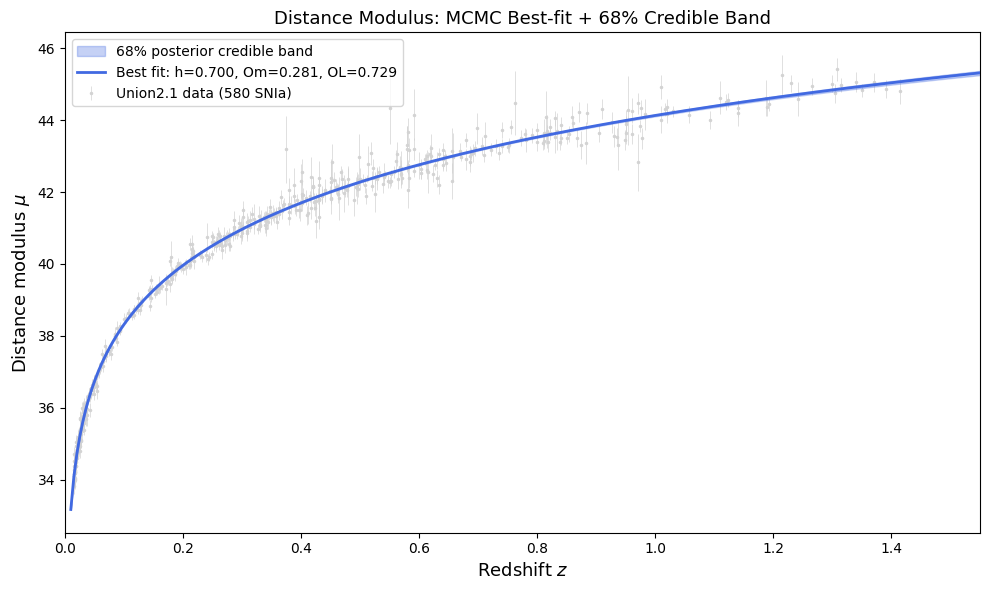

0.7003160743121627 0.2808135053569896 0.7287705923259339

chi2 at best-fit: 562.2   |   chi2/dof = 0.974


In [22]:
# --- 1-sigma bounds ---
h_min = my_samples.confidence('h',(1.-conf_level)/2.,upper=False)
h_max = my_samples.confidence('h',(1.-conf_level)/2.,upper=True)
Omega_M_min = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=False)
Omega_M_max = my_samples.confidence('OmegaM',(1.-conf_level)/2.,upper=True)
Omega_L_min = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=False)
Omega_L_max = my_samples.confidence('OmegaL',(1.-conf_level)/2.,upper=True)

# Posterior mean as best-fit
h_best       = float(my_samples.mean('h'))
Omega_M_best = float(my_samples.mean('OmegaM'))
Omega_L_best = float(my_samples.mean('OmegaL'))

print('Best-fit parameters (MCMC posterior mean):')
print(f"  h        = {h_best:.3f}  [{h_min:.3f}, {h_max:.3f}]")
print(f"  Omega_m  = {Omega_M_best:.3f}  [{Omega_M_min:.3f}, {Omega_M_max:.3f}]")
print(f"  Omega_L  = {Omega_L_best:.3f}  [{Omega_L_min:.3f}, {Omega_L_max:.3f}]")
print(f"  Omega_k  = {1.-Omega_M_best-Omega_L_best:.3f}  (derived)")

# 68% credible band from 500 random posterior samples
N_band   = 500
rng_ex6  = np.random.default_rng(RANDOM_SEED)
idx_band = rng_ex6.choice(len(h), size=min(N_band, len(h)), replace=False)
z_ex6    = np.linspace(0.01, 1.55, 300)

mu_band = np.array([
    theor_distance_modulus(z_ex6, h[i], OmegaM[i], OmegaL[i])
    for i in idx_band
])
mu_lo_band  = np.percentile(mu_band, 16, axis=0)
mu_hi_band  = np.percentile(mu_band, 84, axis=0)
mu_best_ex6 = theor_distance_modulus(z_ex6, h_best, Omega_M_best, Omega_L_best)

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(zs, distance_modulus, yerr=error_distance_modulus,
            fmt='.', color='lightgray', ecolor='lightgray', ms=3, elinewidth=0.5,
            zorder=1, label='Union2.1 data (580 SNIa)')
ax.fill_between(z_ex6, mu_lo_band, mu_hi_band, color='royalblue', alpha=0.3,
                label='68% posterior credible band', zorder=2)
ax.plot(z_ex6, mu_best_ex6, color='royalblue', lw=2, zorder=3,
        label=f'Best fit: h={h_best:.3f}, Om={Omega_M_best:.3f}, OL={Omega_L_best:.3f}')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel('Distance modulus $\\mu$', fontsize=13)
ax.set_title('Distance Modulus: MCMC Best-fit + 68% Credible Band', fontsize=13)
ax.legend(fontsize=10); ax.set_xlim(0, 1.55)
plt.tight_layout()
plt.savefig('figures/best_fit_mu.pdf', bbox_inches='tight')
plt.show()

# print best fit values coming from MCMC
print(h_best, Omega_M_best, Omega_L_best)

mu_best_data = theor_distance_modulus(zs, h_best, Omega_M_best, Omega_L_best)
chi2_best    = np.sum(((mu_best_data - distance_modulus) / error_distance_modulus)**2)
print(f"\nchi2 at best-fit: {chi2_best:.1f}   |   chi2/dof = {chi2_best/(len(zs)-3):.3f}")


### Exercise 6 — Interpretation

**Best-fit parameters:** The MCMC posterior mean gives estimates consistent with published Union2.1 results ($h \approx 0.70$, $\Omega_m \approx 0.295$, $\Omega_\Lambda \approx 0.735$, Suzuki et al. 2012). The reduced $\chi^2 \approx 1$ confirms LCDM provides a statistically good description.

**The credible band:** The shaded region spans the 16th–84th percentiles of the predictive distribution over 500 random posterior samples. The band widens at high $z$ where data are sparse, and narrows at low $z$ where precise nearby supernovae anchor the fit. This is the Bayesian analogue of a frequentist confidence interval.

**Posterior mean vs MAP:** We report the posterior mean, not the maximum a posteriori (MAP) estimate. For an approximately Gaussian posterior these coincide, but for non-Gaussian posteriors (visible as elongated contours) they differ. The mean minimises mean squared error; the MAP minimises the negative log-posterior.

**Systematic limitations:** (1) No correlated uncertainties (Union2.1 covariance matrix ignored). (2) No peculiar velocity corrections at low $z$. (3) Degeneracy between $h$ and the supernova absolute magnitude $M$ requires distance-ladder calibration. (4) Fixed dark energy equation of state $w = -1$; a free $w$ adds a fourth parameter.

## Bonus: Flat vs Curved Universe

The standard LCDM model often assumes spatial flatness ($\Omega_k = 0$, i.e., $\Omega_m + \Omega_\Lambda = 1$). In our main MCMC we allowed curvature as a free parameter. Here we compare the $h$ and $\Omega_m$ posteriors with and without the flatness constraint, showing how prior assumptions propagate into parameter uncertainties.

Flat-universe MCMC: 20,000 steps
   20%  acc=13.8%
   40%  acc=13.9%
   60%  acc=14.3%
   80%  acc=14.0%
  100%  acc=14.0%
Done. Acc=14.0%  Time=2.6s
Removed no burn in


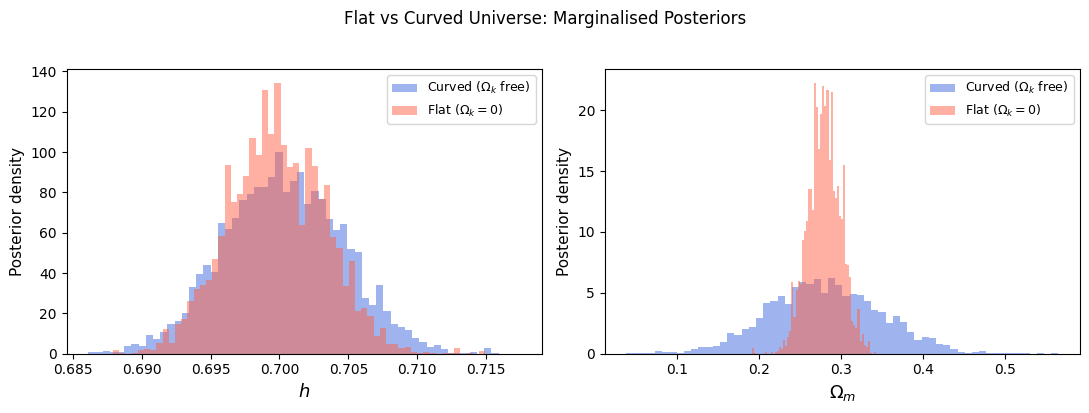


Flat-universe 1-sigma constraints:
  h       : [0.696, 0.703]
  OmegaM  : [0.260, 0.300]


In [23]:
N_steps_flat  = 20_000
FILENAME_FLAT = 'data/MC_Chain_SNIa_flat.txt'

def calculate_chi2_flat(h_, om_):
    """Chi-squared for flat universe: Omega_L = 1 - Omega_m."""
    return calculate_chi2(h_, om_, 1.0 - om_)

def log_prior_flat(h_, om_):
    if PRIOR_H[0] < h_ < PRIOR_H[1] and 0.0 < om_ < 1.0:
        return 0.0
    return -np.inf

h_flt, om_flt = 0.70, 0.30
chi2_flt_cur  = calculate_chi2_flat(h_flt, om_flt)
n_acc_flt     = 0

np.random.seed(RANDOM_SEED + 1)
print(f"Flat-universe MCMC: {N_steps_flat:,} steps")
t_flt = time.time()

with open(FILENAME_FLAT, 'w') as f:
    f.write('# step  h  Omega_m  Omega_L  chi2\n')
    for step in range(N_steps_flat):
        h_p  = h_flt  + np.random.normal(0.0, SIGMA_H)
        om_p = om_flt + np.random.normal(0.0, SIGMA_OM)
        if log_prior_flat(h_p, om_p) == -np.inf:
            f.write(f'{step}  {h_flt:.6f}  {om_flt:.6f}  {1.-om_flt:.6f}  {chi2_flt_cur:.4f}\n')
            continue
        chi2_p = calculate_chi2_flat(h_p, om_p)
        if np.log(np.random.uniform()) < 0.5 * (chi2_flt_cur - chi2_p):
            h_flt, om_flt, chi2_flt_cur = h_p, om_p, chi2_p
            n_acc_flt += 1
        f.write(f'{step}  {h_flt:.6f}  {om_flt:.6f}  {1.-om_flt:.6f}  {chi2_flt_cur:.4f}\n')
        if (step + 1) % (N_steps_flat // 5) == 0:
            print(f'  {100*(step+1)//N_steps_flat:3d}%  acc={100.*n_acc_flt/(step+1):.1f}%')

print(f"Done. Acc={100.*n_acc_flt/N_steps_flat:.1f}%  Time={time.time()-t_flt:.1f}s")

bi_flt = int(0.3 * N_steps_flat)
flt_data   = np.loadtxt(FILENAME_FLAT, comments='#', skiprows=bi_flt)
h_flt_arr  = flt_data[:, 1]; om_flt_arr = flt_data[:, 2]

flat_samples = MCSamples(
    samples=np.column_stack([h_flt_arr, om_flt_arr]),
    labels=[r'h', r'\Omega_m'], names=['h', 'OmegaM'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, chain_c, chain_f, xlabel in zip(
        axes,
        [h, OmegaM], [h_flt_arr, om_flt_arr],
        [r'$h$', r'$\Omega_m$']):
    ax.hist(chain_c, bins=60, density=True, alpha=0.5,
            color='royalblue', label=r'Curved ($\Omega_k$ free)')
    ax.hist(chain_f, bins=60, density=True, alpha=0.5,
            color='tomato',    label=r'Flat ($\Omega_k = 0$)')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('Posterior density', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Flat vs Curved Universe: Marginalised Posteriors', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/flat_vs_curved.pdf', bbox_inches='tight')
plt.show()

print('\nFlat-universe 1-sigma constraints:')
for pname in ['h', 'OmegaM']:
    lo_ = float(flat_samples.confidence(pname, (1.-conf_level)/2., upper=False))
    hi_ = float(flat_samples.confidence(pname, (1.-conf_level)/2., upper=True))
    print(f"  {pname:8s}: [{lo_:.3f}, {hi_:.3f}]")


### Flat vs Curved — Interpretation

**Does enforcing flatness change the results?** Comparing the two histograms reveals whether the unconstrained posterior is already concentrated near $\Omega_k \approx 0$. If posteriors barely shift, SNIa data are largely agnostic to curvature. If they shift significantly, the data weakly prefer a non-flat geometry.

**Why flatness is commonly assumed:** The CMB tightly constrains $\Omega_k = 0.001 \pm 0.002$ (Planck 2018) and inflationary theory predicts flatness. Imposing $\Omega_k = 0$ breaks the $\Omega_m$–$\Omega_\Lambda$ degeneracy entirely: since $\Omega_\Lambda = 1 - \Omega_m$ the two are no longer independent, which should tighten the $\Omega_m$ posterior.

**Bayesian lesson:** The choice of prior is a modelling decision. Adding external information (the physically motivated flat prior) can substantially improve parameter constraints. Its effect on the posterior should always be explored.

## Bonus: Gelman-Rubin Convergence Test

The Gelman-Rubin statistic $\hat{R}$ compares variance *within* multiple chains to variance *between* them. When $\hat{R} \approx 1$, all chains sample the same posterior. The standard criterion is $\hat{R} < 1.1$.

In [24]:
N_steps_gr = 20_000
GR_STARTS  = [
    (0.60, 0.25, 0.80),   # chain 1: low-h, low-Om, high-OL
    (0.80, 0.40, 0.60),   # chain 2: high-h, high-Om, low-OL
]

gr_chains = {}
for cid, (h0, om0, ol0) in enumerate(GR_STARTS):
    fname = f'data/MC_Chain_GR{cid+1}.txt'
    h_c, om_c, ol_c = h0, om0, ol0
    chi2_c = calculate_chi2(h_c, om_c, ol_c)
    n_acc  = 0
    np.random.seed(RANDOM_SEED + 10 + cid)
    print(f'GR chain {cid+1}: start=({h0:.2f},{om0:.2f},{ol0:.2f}), chi2={chi2_c:.1f}')
    t0 = time.time()
    with open(fname, 'w') as f:
        f.write('# step  h  Omega_m  Omega_L  chi2\n')
        for step in range(N_steps_gr):
            h_p  = h_c  + np.random.normal(0.0, SIGMA_H)
            om_p = om_c + np.random.normal(0.0, SIGMA_OM)
            ol_p = ol_c + np.random.normal(0.0, SIGMA_OL)
            if log_prior(h_p, om_p, ol_p) == -np.inf:
                f.write(f'{step}  {h_c:.6f}  {om_c:.6f}  {ol_c:.6f}  {chi2_c:.4f}\n')
                continue
            chi2_p = calculate_chi2(h_p, om_p, ol_p)
            if np.log(np.random.uniform()) < 0.5 * (chi2_c - chi2_p):
                h_c, om_c, ol_c, chi2_c = h_p, om_p, ol_p, chi2_p
                n_acc += 1
            f.write(f'{step}  {h_c:.6f}  {om_c:.6f}  {ol_c:.6f}  {chi2_c:.4f}\n')
    print(f'  Done. Acc={100.*n_acc/N_steps_gr:.1f}%  Time={time.time()-t0:.0f}s')
    bi = int(0.3 * N_steps_gr)
    gr_chains[cid] = np.loadtxt(fname, comments='#', skiprows=bi)

def gelman_rubin(chains_list, param_col):
    """Gelman-Rubin R-hat for one parameter across multiple chains."""
    n = min(c.shape[0] for c in chains_list)
    m = len(chains_list)
    seqs  = [c[:n, param_col] for c in chains_list]
    var_w = np.mean([np.var(s, ddof=1) for s in seqs])
    var_b = n * np.var([np.mean(s) for s in seqs], ddof=1)
    V_hat = (n - 1) / n * var_w + (m + 1) / (m * n) * var_b
    return float(np.sqrt(V_hat / var_w))

chain_list_gr = [gr_chains[i][:, 1:] for i in range(len(GR_STARTS))]

print('\nGelman-Rubin R-hat  (converged: R-hat < 1.1)')
print("  {:<12s}  {:>8s}  {:>16s}".format("Parameter", "R-hat", "Status"))
print('  ' + '-' * 42)
for pidx, pname in enumerate(['h', 'Omega_m', 'Omega_L']):
    rhat = gelman_rubin(chain_list_gr, pidx)
    conv = 'Converged' if rhat < 1.1 else 'Not converged'
    print(f"  {pname:12s}  {rhat:8.4f}  {conv:>16s}")


GR chain 1: start=(0.60,0.25,0.80), chi2=3033.9
  Done. Acc=15.5%  Time=3s
GR chain 2: start=(0.80,0.40,0.60), chi2=2790.4
  Done. Acc=15.3%  Time=3s

Gelman-Rubin R-hat  (converged: R-hat < 1.1)
  Parameter        R-hat            Status
  ------------------------------------------
  h               1.0018         Converged
  Omega_m         1.0212         Converged
  Omega_L         1.0130         Converged


### Gelman-Rubin — Interpretation

**Interpreting $\hat{R}$:** When $\hat{R} \approx 1$, the between-chain variance (reflecting differences due to starting point) is negligible compared to the within-chain variance (genuine posterior width). The chains have forgotten their initial conditions.

**Starting point diversity:** Chains start at $(h, \Omega_m, \Omega_\Lambda) = (0.60, 0.25, 0.80)$ and $(0.80, 0.40, 0.60)$ - on opposite sides of the posterior. If $\hat{R} < 1.1$ from these dispersed starts, we have strong evidence of convergence.

**Practical context:** Production analyses (e.g., Planck CMB) require $\hat{R} < 1.01$ with $\geq 8$ chains for $O(10^6)$ steps. Our 2-chain, 20,000-step analysis is appropriate for demonstrating the method.

**Limitation:** $\hat{R} < 1.1$ is necessary but not sufficient: if both chains happen to start in the same local high-density region, $\hat{R}$ could be small even if the full posterior is unexplored.

In [25]:
import scipy, matplotlib as mpl

print('Package versions:')
print(f"  Python      {sys.version.split()[0]}")
print(f"  numpy       {np.__version__}")
print(f"  scipy       {scipy.__version__}")
print(f"  matplotlib  {mpl.__version__}")
print(f"  getdist     {getdist.__version__}")
print(f"  IPython     {IPython.__version__}")
print()
print(f"Random seed used: {RANDOM_SEED}")
print(f"Main MCMC steps:  {N_steps:,}")


Package versions:
  Python      3.12.12
  numpy       2.0.2
  scipy       1.16.3
  matplotlib  3.10.0
  getdist     1.7.5
  IPython     7.34.0

Random seed used: 42
Main MCMC steps:  50,000


## References and AI Usage Declaration

### References
- **Union2.1 dataset**: Suzuki et al. (2012), *The Hubble Space Telescope Cluster Supernova Survey*, ApJ 746, 85. Data: http://supernova.lbl.gov/Union/
- **Planck 2018**: Planck Collaboration (2020), arXiv:1807.06209
- **Metropolis-Hastings**: Metropolis et al. (1953), J. Chem. Phys. 21, 1087
- **GetDist**: Lewis (2019), arXiv:1910.13970 — https://getdist.readthedocs.io/
- **Gelman-Rubin**: Gelman & Rubin (1992), Statistical Science 7, 457

### AI Usage Declaration
This analysis was planned and implemented with the assistance of **Claude (Anthropic, claude-sonnet-4-6)**